FOREST FIRE RISK PREDICTION

Dataset Shape:
(517, 13)

First 5 Rows:
   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   tem

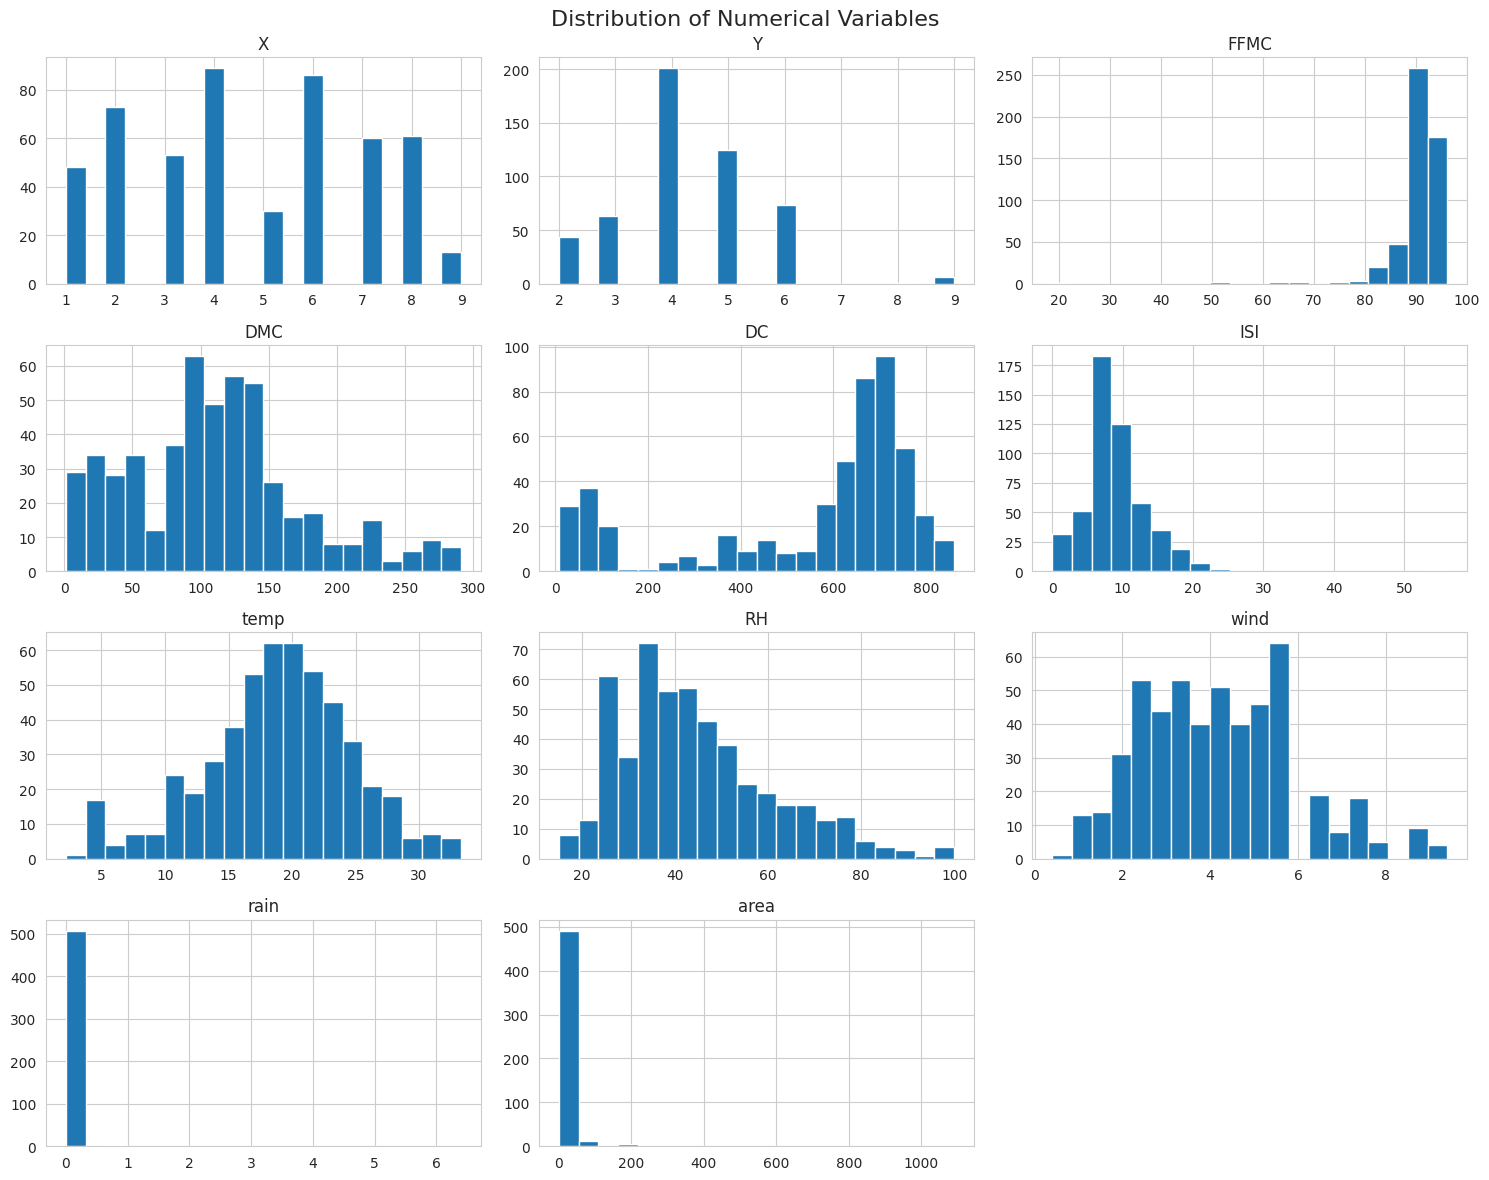

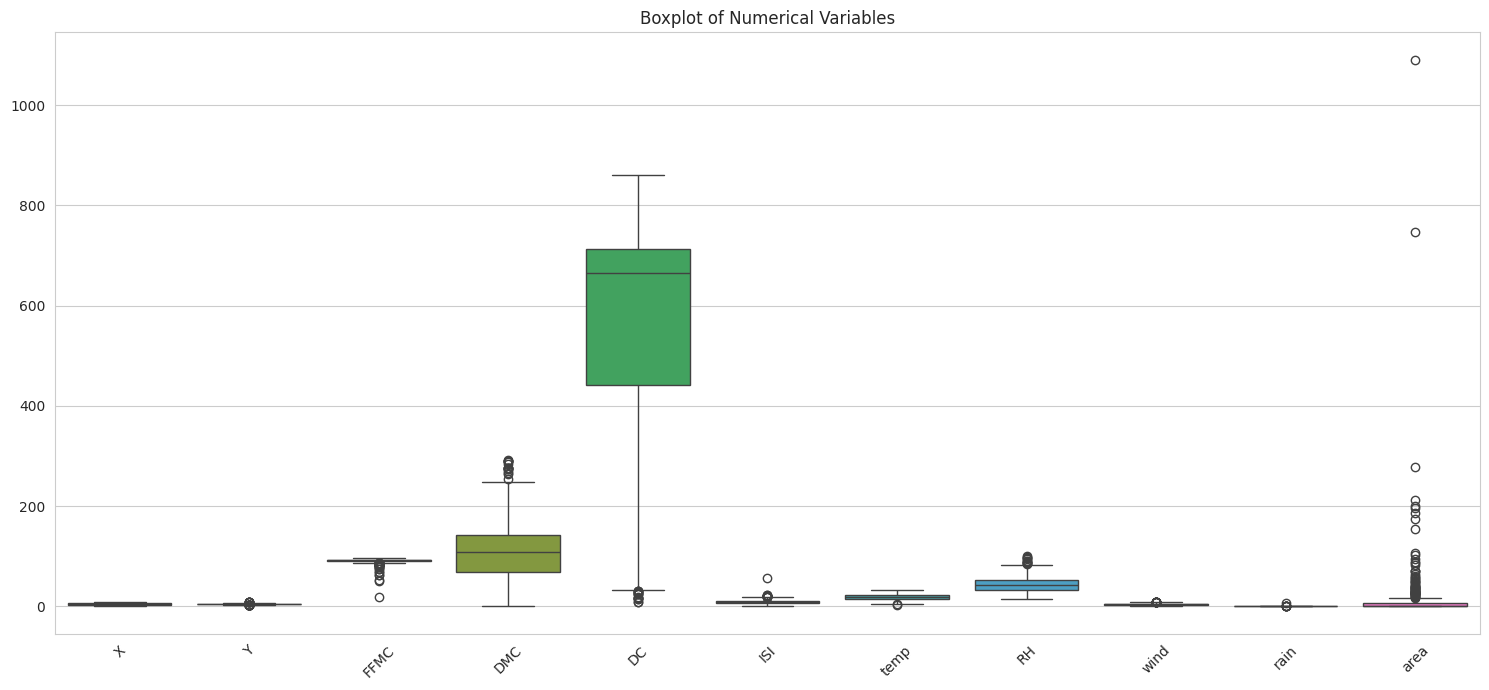

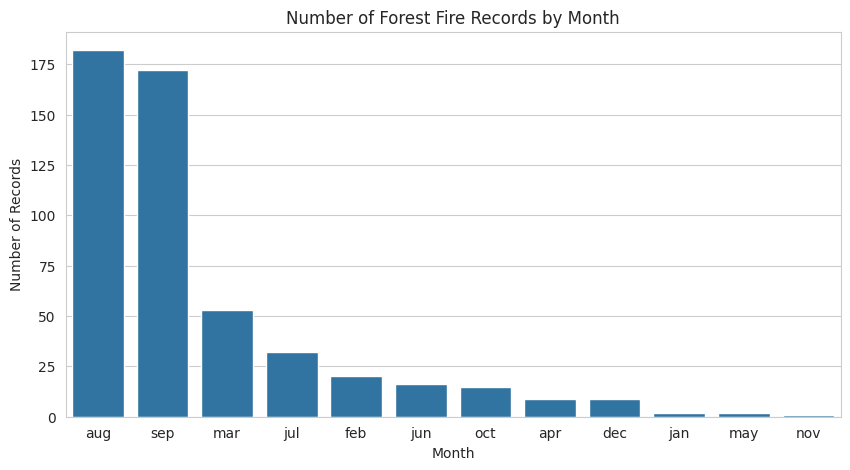

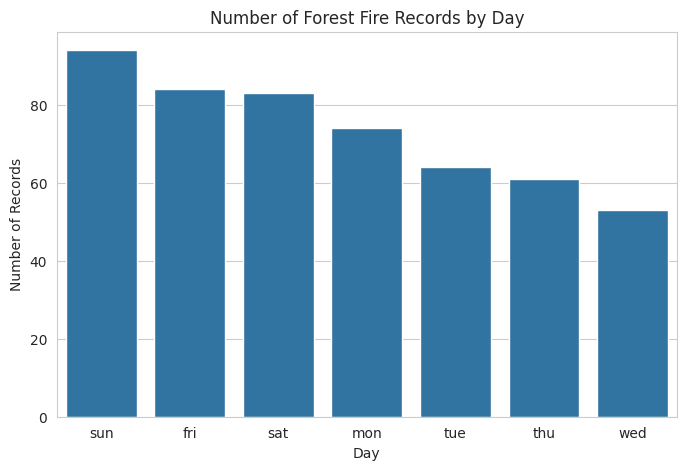

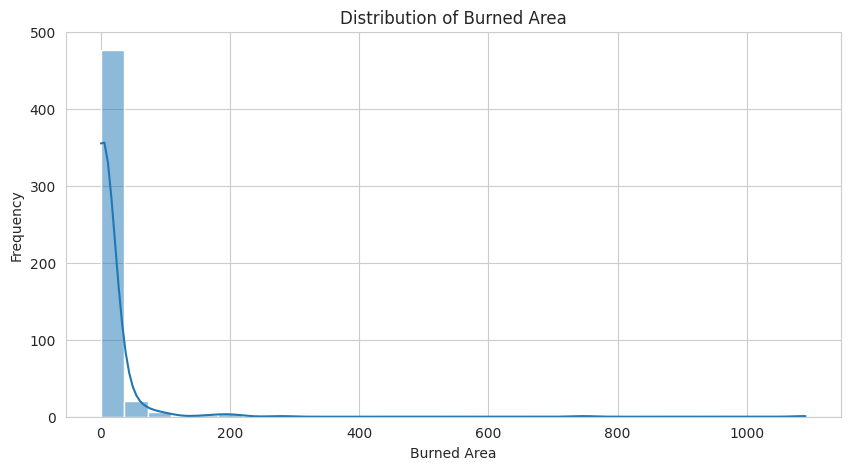

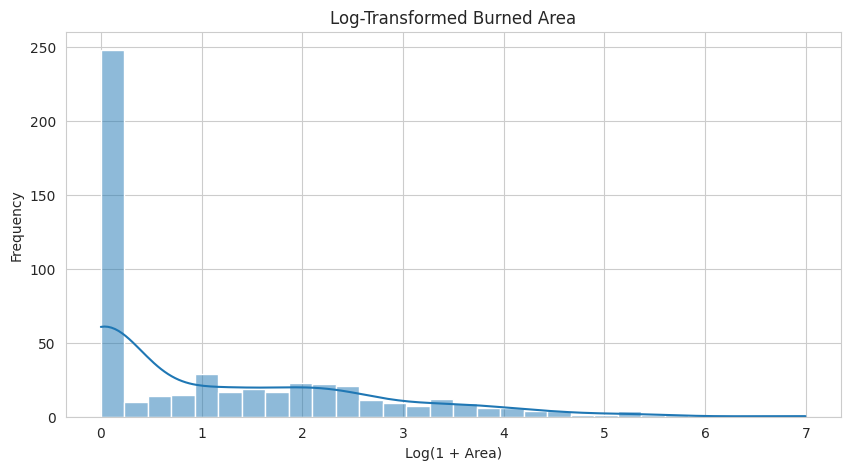

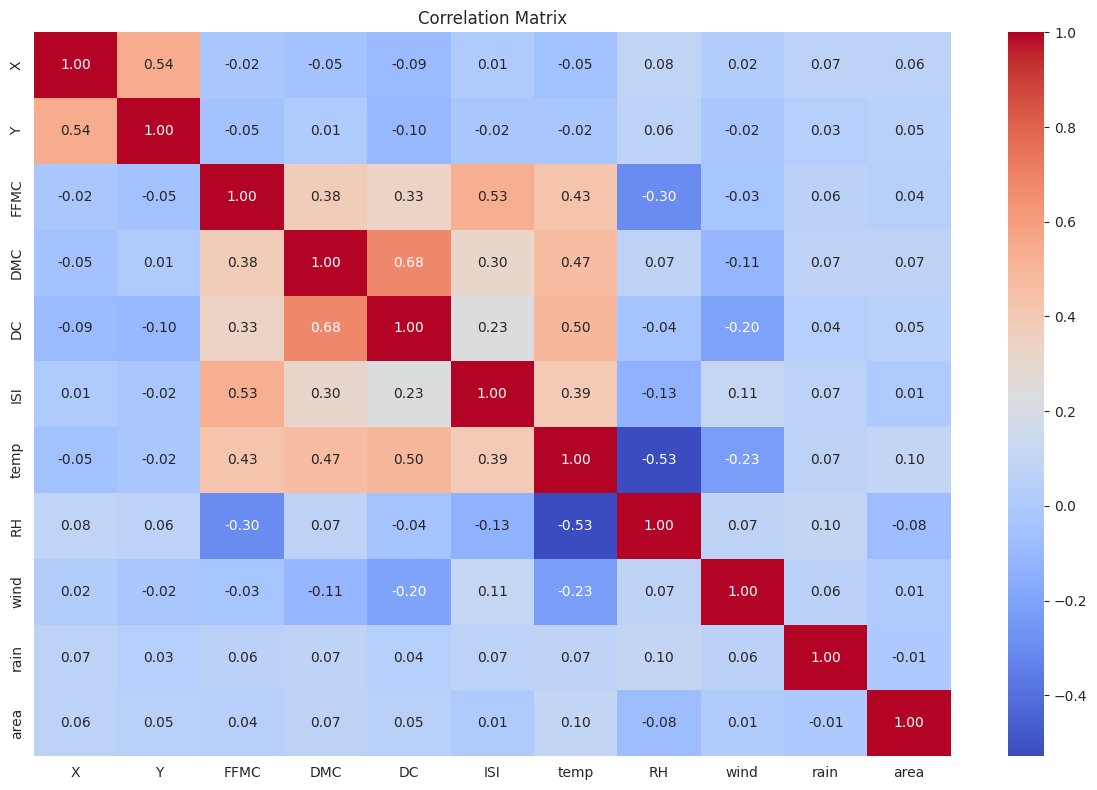


Correlation with Burned Area:
area    1.000000
temp    0.098222
DMC     0.073783
X       0.062930
DC      0.050313
Y       0.045168
FFMC    0.040232
wind    0.012699
ISI     0.008411
rain   -0.007418
RH     -0.075460
Name: area, dtype: float64


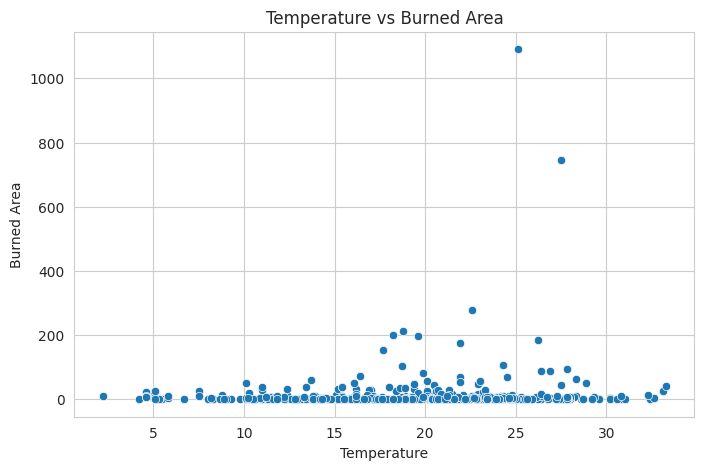

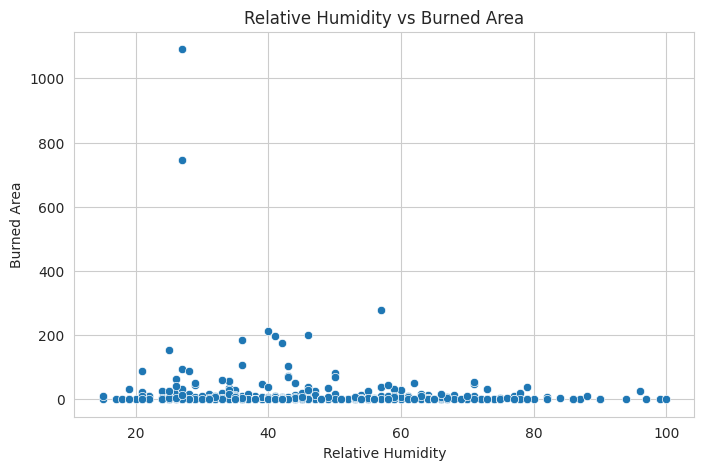

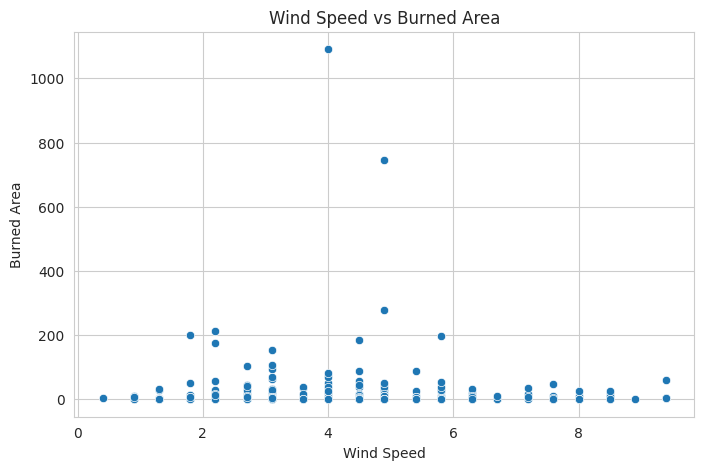

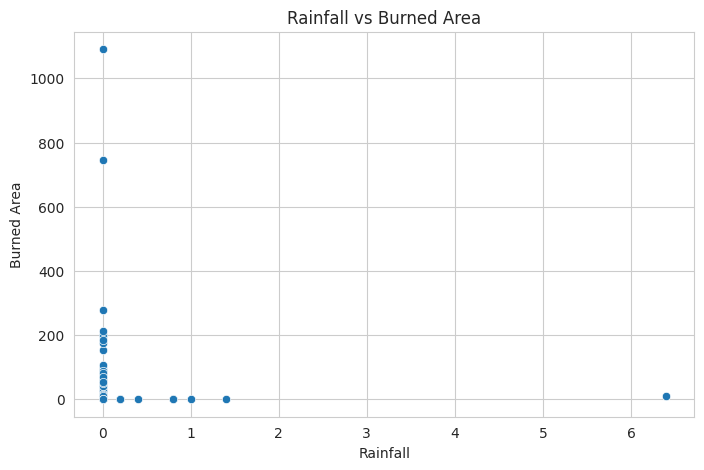


Average Burned Area by Month:
month
may    19.240000
sep    17.942616
jul    14.369687
dec    13.330000
aug    12.626319
apr     8.891111
oct     6.638000
feb     6.275000
jun     6.206250
mar     3.898113
jan     0.000000
nov     0.000000
Name: area, dtype: float64


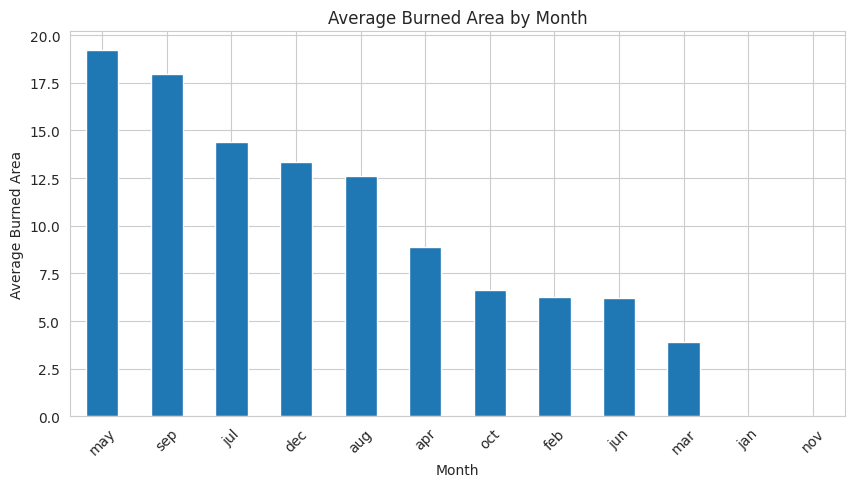


Number of Burned Area Outliers:
62

Features:
['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']

Target Variable:
area

Training Samples: 410
Testing Samples: 103

RANDOM FOREST RESULTS
MAE  : 19.1501
MSE  : 1299.3753
RMSE : 36.0468
R²   : -2.3741

GRADIENT BOOSTING RESULTS
MAE  : 21.7212
MSE  : 1554.0329
RMSE : 39.4212
R²   : -3.0354

MODEL COMPARISON
            Model       MAE         MSE      RMSE  R2 Score
    Random Forest 19.150113 1299.375295 36.046849 -2.374126
Gradient Boosting 21.721203 1554.032925 39.421224 -3.035403


<Figure size 1000x600 with 0 Axes>

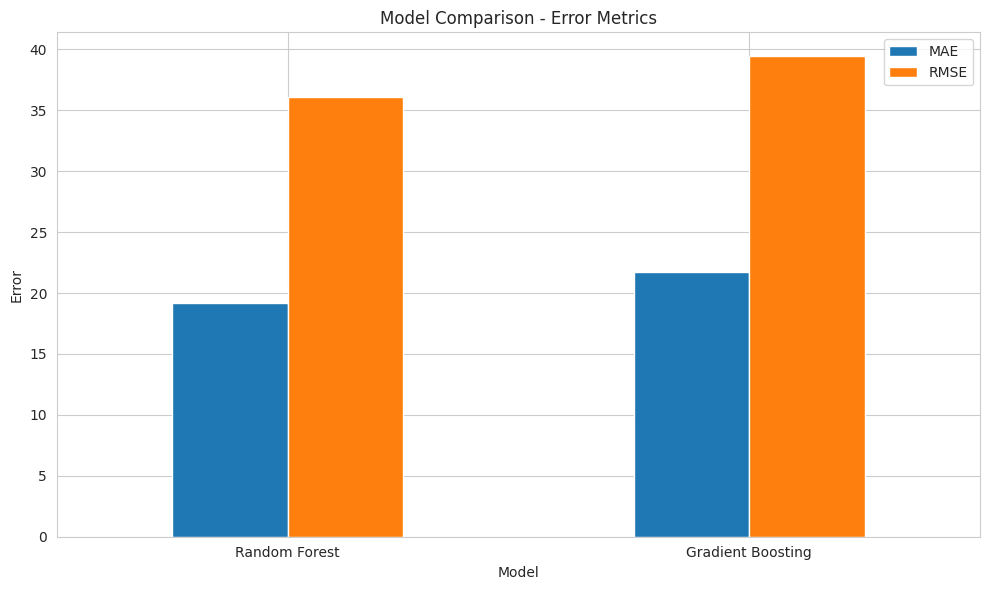

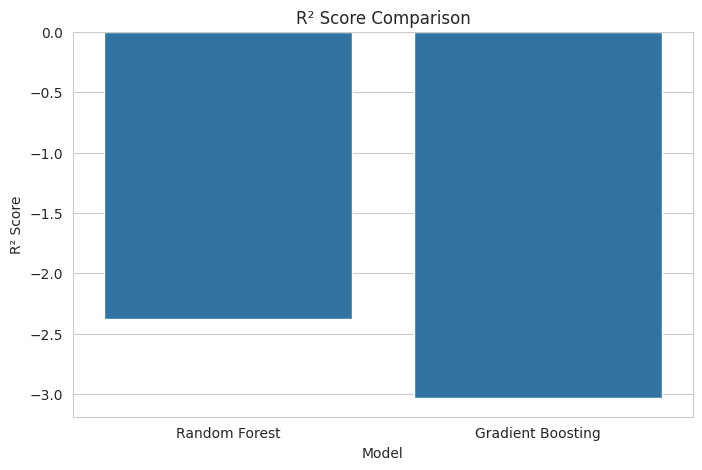

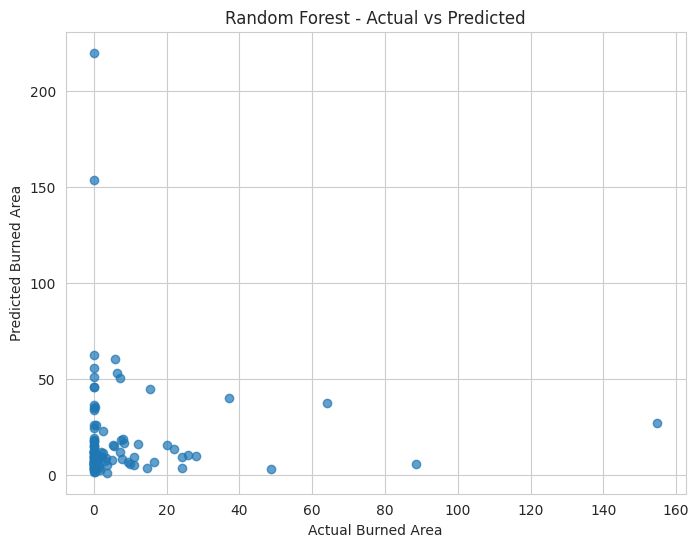

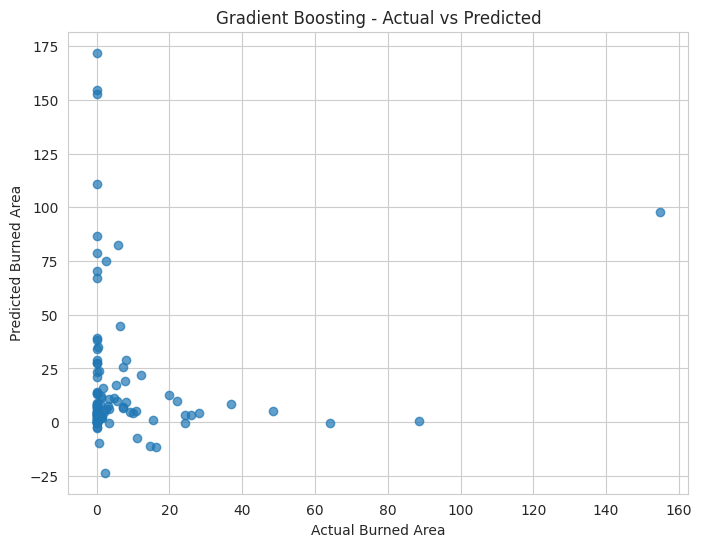


TOP FEATURES - RANDOM FOREST
               Feature  Importance
       numerical__temp    0.443082
        numerical__DMC    0.100383
       numerical__wind    0.077165
         numerical__RH    0.059985
       numerical__FFMC    0.052649
          numerical__Y    0.051010
        numerical__ISI    0.047259
         numerical__DC    0.036536
          numerical__X    0.031146
  categorical__day_thu    0.025463
  categorical__day_sat    0.017138
  categorical__day_mon    0.011539
categorical__month_sep    0.011026
  categorical__day_tue    0.009573
categorical__month_jul    0.007276


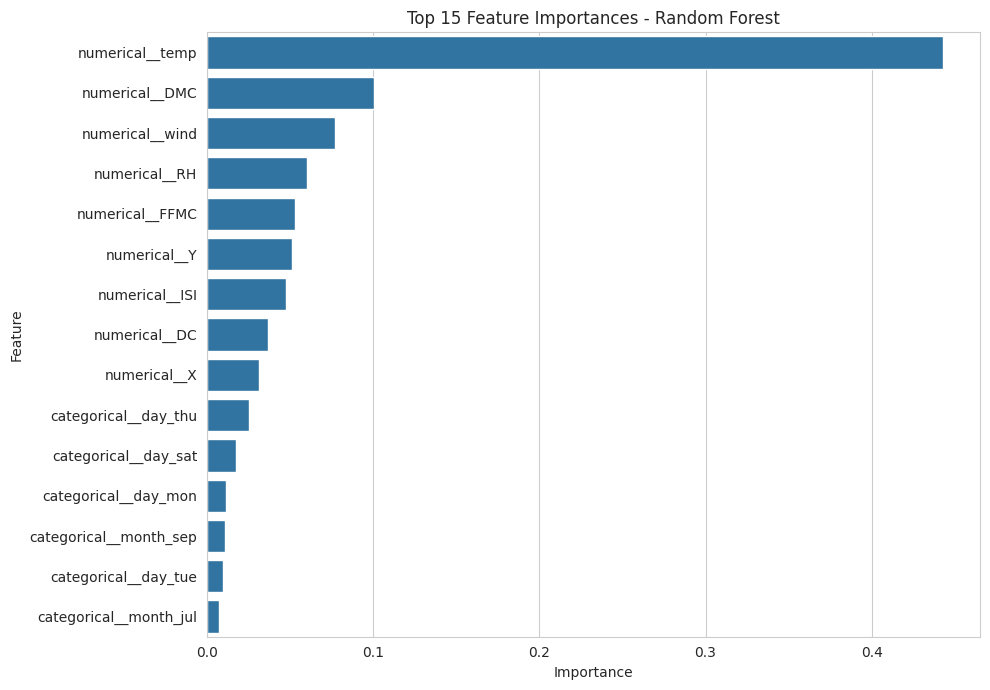


TOP FEATURES - GRADIENT BOOSTING
               Feature  Importance
       numerical__temp    0.647364
        numerical__DMC    0.090799
        numerical__ISI    0.057262
       numerical__wind    0.048520
       numerical__FFMC    0.026976
         numerical__DC    0.026515
          numerical__X    0.024911
         numerical__RH    0.022995
          numerical__Y    0.022654
  categorical__day_thu    0.020476
  categorical__day_mon    0.002447
categorical__month_sep    0.002158
  categorical__day_tue    0.001643
categorical__month_jul    0.001595
  categorical__day_sat    0.001219


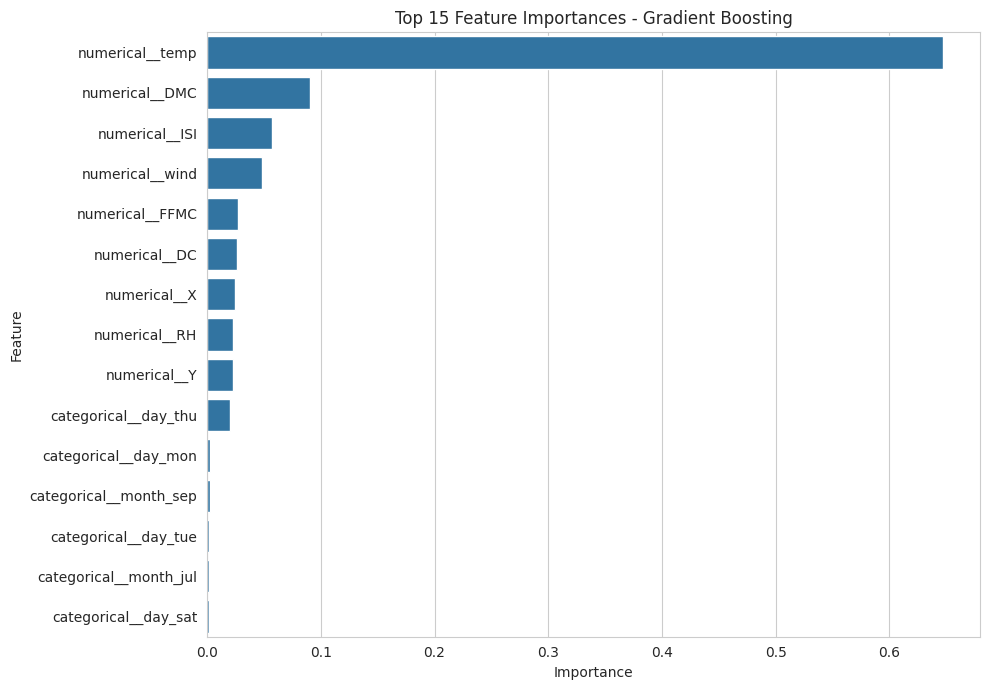


FIRE RISK DISTRIBUTION
fire_risk
Low       244
Medium    175
High       94
Name: count, dtype: int64


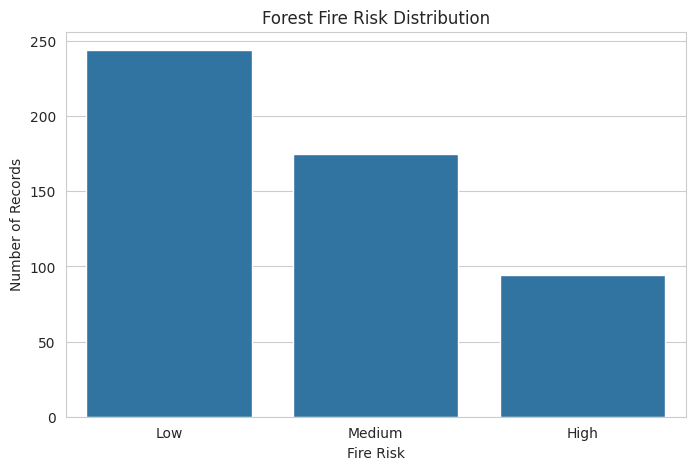


FINAL RESULTS

Random Forest R²: -2.3741
Gradient Boosting R²: -3.0354

Best Performing Model: Random Forest
Best R² Score: -2.3741

PROJECT SUMMARY

The Forest Fire dataset was analyzed using Exploratory Data
Analysis techniques including statistical analysis, distributions,
boxplots, correlation analysis, and outlier detection.

The data was preprocessed using one-hot encoding for categorical
variables such as month and day.

Two machine learning models were trained:

1. Random Forest Regressor
2. Gradient Boosting Regressor

The models were evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the higher R² score is considered the better
performing model for predicting burned area.

Fire risk categories were also generated as Low, Medium, and High
based on the predicted/observed burned area.



In [1]:
# ============================================================
# FOREST FIRE RISK PREDICTION
# Using Random Forest and Gradient-Boosted Trees
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("forestfires.csv")

print("=" * 60)
print("FOREST FIRE RISK PREDICTION")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


# ============================================================
# 2. DATA QUALITY CHECK
# ============================================================

print("\n" + "=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)


# ============================================================
# 3. IDENTIFY COLUMNS
# ============================================================

categorical_columns = ['month', 'day']

numerical_columns = [
    'X',
    'Y',
    'FFMC',
    'DMC',
    'DC',
    'ISI',
    'temp',
    'RH',
    'wind',
    'rain'
]

print("\nCategorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)


# ============================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================

# Distribution of numerical variables
df[numerical_columns + ['area']].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()


# Boxplot
plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df[numerical_columns + ['area']]
)

plt.title("Boxplot of Numerical Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Month distribution
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='month',
    order=df['month'].value_counts().index
)

plt.title("Number of Forest Fire Records by Month")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.show()


# Day distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='day',
    order=df['day'].value_counts().index
)

plt.title("Number of Forest Fire Records by Day")
plt.xlabel("Day")
plt.ylabel("Number of Records")
plt.show()


# Burned area distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df['area'],
    bins=30,
    kde=True
)

plt.title("Distribution of Burned Area")
plt.xlabel("Burned Area")
plt.ylabel("Frequency")
plt.show()


# Log-transformed area
df['log_area'] = np.log1p(df['area'])

plt.figure(figsize=(10, 5))

sns.histplot(
    df['log_area'],
    bins=30,
    kde=True
)

plt.title("Log-Transformed Burned Area")
plt.xlabel("Log(1 + Area)")
plt.ylabel("Frequency")
plt.show()


# ============================================================
# 5. CORRELATION ANALYSIS
# ============================================================

correlation_columns = numerical_columns + ['area']

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


print("\nCorrelation with Burned Area:")
print(
    correlation_matrix['area']
    .sort_values(ascending=False)
)


# ============================================================
# 6. BIVARIATE ANALYSIS
# ============================================================

# Temperature vs area
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='temp',
    y='area'
)

plt.title("Temperature vs Burned Area")
plt.xlabel("Temperature")
plt.ylabel("Burned Area")
plt.show()


# Humidity vs area
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='RH',
    y='area'
)

plt.title("Relative Humidity vs Burned Area")
plt.xlabel("Relative Humidity")
plt.ylabel("Burned Area")
plt.show()


# Wind vs area
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='wind',
    y='area'
)

plt.title("Wind Speed vs Burned Area")
plt.xlabel("Wind Speed")
plt.ylabel("Burned Area")
plt.show()


# Rain vs area
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='rain',
    y='area'
)

plt.title("Rainfall vs Burned Area")
plt.xlabel("Rainfall")
plt.ylabel("Burned Area")
plt.show()


# ============================================================
# 7. MONTHLY ANALYSIS
# ============================================================

monthly_area = df.groupby('month')['area'].mean()

print("\nAverage Burned Area by Month:")
print(monthly_area.sort_values(ascending=False))


plt.figure(figsize=(10, 5))

monthly_area.sort_values(ascending=False).plot(
    kind='bar'
)

plt.title("Average Burned Area by Month")
plt.xlabel("Month")
plt.ylabel("Average Burned Area")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 8. OUTLIER DETECTION
# ============================================================

Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['area'] < lower_bound) |
    (df['area'] > upper_bound)
]

print("\nNumber of Burned Area Outliers:")
print(len(outliers))


# ============================================================
# 9. PREPARE DATA FOR MACHINE LEARNING
# ============================================================

# Target variable
X = df.drop(columns=['area', 'log_area'])
y = df['area']

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("area")


# ============================================================
# 10. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_columns
        ),
        (
            'numerical',
            'passthrough',
            numerical_columns
        )
    ]
)


# ============================================================
# 11. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# ============================================================
# 12. RANDOM FOREST REGRESSOR
# ============================================================

random_forest_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(X_test)


# ============================================================
# 13. RANDOM FOREST EVALUATION
# ============================================================

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_mse = mean_squared_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("\n" + "=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print("MAE  :", round(rf_mae, 4))
print("MSE  :", round(rf_mse, 4))
print("RMSE :", round(rf_rmse, 4))
print("R²   :", round(rf_r2, 4))


# ============================================================
# 14. GRADIENT BOOSTING REGRESSOR
# ============================================================

gradient_boosting_model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gradient_boosting_model.fit(
    X_train,
    y_train
)

gb_predictions = gradient_boosting_model.predict(X_test)


# ============================================================
# 15. GRADIENT BOOSTING EVALUATION
# ============================================================

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_mse = mean_squared_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(gb_mse)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print("\n" + "=" * 60)
print("GRADIENT BOOSTING RESULTS")
print("=" * 60)

print("MAE  :", round(gb_mae, 4))
print("MSE  :", round(gb_mse, 4))
print("RMSE :", round(gb_rmse, 4))
print("R²   :", round(gb_r2, 4))


# ============================================================
# 16. MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        rf_mae,
        gb_mae
    ],
    'MSE': [
        rf_mse,
        gb_mse
    ],
    'RMSE': [
        rf_rmse,
        gb_rmse
    ],
    'R2 Score': [
        rf_r2,
        gb_r2
    ]
})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(results.to_string(index=False))


# ============================================================
# 17. MODEL PERFORMANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

results_plot = results.set_index('Model')

results_plot[['MAE', 'RMSE']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Model Comparison - Error Metrics")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# R2 comparison
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title("R² Score Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.show()


# ============================================================
# 18. ACTUAL VS PREDICTED - RANDOM FOREST
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.7
)

plt.xlabel("Actual Burned Area")
plt.ylabel("Predicted Burned Area")

plt.title("Random Forest - Actual vs Predicted")

plt.show()


# ============================================================
# 19. ACTUAL VS PREDICTED - GRADIENT BOOSTING
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    gb_predictions,
    alpha=0.7
)

plt.xlabel("Actual Burned Area")
plt.ylabel("Predicted Burned Area")

plt.title("Gradient Boosting - Actual vs Predicted")

plt.show()


# ============================================================
# 20. FEATURE IMPORTANCE - RANDOM FOREST
# ============================================================

rf_preprocessor = (
    random_forest_model
    .named_steps['preprocessor']
)

rf_model = (
    random_forest_model
    .named_steps['model']
)

rf_feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

rf_importances = rf_model.feature_importances_

rf_feature_importance = pd.DataFrame({
    'Feature': rf_feature_names,
    'Importance': rf_importances
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

print("\n" + "=" * 60)
print("TOP FEATURES - RANDOM FOREST")
print("=" * 60)

print(
    rf_feature_importance
    .head(15)
    .to_string(index=False)
)


plt.figure(figsize=(10, 7))

sns.barplot(
    data=rf_feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()


# ============================================================
# 21. FEATURE IMPORTANCE - GRADIENT BOOSTING
# ============================================================

gb_preprocessor = (
    gradient_boosting_model
    .named_steps['preprocessor']
)

gb_model = (
    gradient_boosting_model
    .named_steps['model']
)

gb_feature_names = (
    gb_preprocessor
    .get_feature_names_out()
)

gb_importances = gb_model.feature_importances_

gb_feature_importance = pd.DataFrame({
    'Feature': gb_feature_names,
    'Importance': gb_importances
})

gb_feature_importance = (
    gb_feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

print("\n" + "=" * 60)
print("TOP FEATURES - GRADIENT BOOSTING")
print("=" * 60)

print(
    gb_feature_importance
    .head(15)
    .to_string(index=False)
)


plt.figure(figsize=(10, 7))

sns.barplot(
    data=gb_feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.tight_layout()
plt.show()


# ============================================================
# 22. FIRE RISK CATEGORIZATION
# ============================================================

def assign_risk(area):
    if area == 0:
        return "Low"
    elif area <= 10:
        return "Medium"
    else:
        return "High"


df['fire_risk'] = df['area'].apply(assign_risk)

print("\n" + "=" * 60)
print("FIRE RISK DISTRIBUTION")
print("=" * 60)

print(
    df['fire_risk']
    .value_counts()
)


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='fire_risk',
    order=['Low', 'Medium', 'High']
)

plt.title("Forest Fire Risk Distribution")
plt.xlabel("Fire Risk")
plt.ylabel("Number of Records")

plt.show()


# ============================================================
# 23. FINAL MODEL SELECTION
# ============================================================

if rf_r2 > gb_r2:
    best_model = "Random Forest"
    best_r2 = rf_r2
else:
    best_model = "Gradient Boosting"
    best_r2 = gb_r2


print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print("\nRandom Forest R²:", round(rf_r2, 4))
print("Gradient Boosting R²:", round(gb_r2, 4))

print("\nBest Performing Model:", best_model)
print("Best R² Score:", round(best_r2, 4))


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print("""
The Forest Fire dataset was analyzed using Exploratory Data
Analysis techniques including statistical analysis, distributions,
boxplots, correlation analysis, and outlier detection.

The data was preprocessed using one-hot encoding for categorical
variables such as month and day.

Two machine learning models were trained:

1. Random Forest Regressor
2. Gradient Boosting Regressor

The models were evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the higher R² score is considered the better
performing model for predicting burned area.

Fire risk categories were also generated as Low, Medium, and High
based on the predicted/observed burned area.
""")